In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# modelling
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.metrics import r2_score , mean_squared_error , mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
X = df.drop(columns=["math score"] , axis=1)
y = df["math score"]

In [10]:
## create column transformer with 3 type of transformation

num_feature = X.select_dtypes(exclude="object").columns
cat_feature = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transform = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder" , oh_transform , cat_feature) ,
        ("Standard Scalar" , numeric_transformer , num_feature)
    ]
)



In [11]:
X = preprocessor.fit_transform(X)

In [13]:
X.shape

(1000, 19)

In [15]:
# train test split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [16]:
X_train.shape , X_test.shape

((800, 19), (200, 19))

# Create an Evaluate function to give all metrics after training

In [17]:
def evaluate_model(true,  predicted) :
    mae = mean_absolute_error(true , predicted)
    mse = mean_squared_error(true , predicted)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true , predicted)
    return mae , rmse , r2_square

In [20]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso() ,
    "Ridge" : Ridge() ,
    "K-neighbour Regression" : KNeighborsRegressor() ,
    "Decision Tree" : DecisionTreeRegressor() ,
    "Random Forest Regression" : RandomForestRegressor() ,
    "XGBRegression" : XGBRegressor() ,
    "CatBoosting Regression" : CatBoostRegressor() ,
    "AdaBoost Regression" : AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(models)) :
    model = list(models.values())[i]
    model.fit(X_train , y_train) # train model

    # model predict

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    ## evaluate train test dataset

    model_train_mae ,model_train_rmse , model_train_r2_score = evaluate_model(y_train , y_train_pred)
    model_test_mae ,model_test_rmse , model_test_r2_score = evaluate_model(y_test , y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training data")
    print("----RMSE : {:.4f}".format(model_train_rmse))
    print("----MAE : {:.4f}".format(model_train_mae))
    print("----R2 Score : {:.4f}".format(model_train_r2_score))

    print("-"* 32)

    print("Model performance for test data")
    print("----RMSE : {:.4f}".format(model_test_rmse))
    print("----MAE : {:.4f}".format(model_test_mae))
    print("----R2 Score : {:.4f}".format(model_test_r2_score))

    r2_list.append(model_test_r2_score)

    print("=" * 35)
    print("\n")

Linear Regression
Model performance for training data
----RMSE : 5.3257
----MAE : 4.2695
----R2 Score : 0.8742
--------------------------------
Model performance for test data
----RMSE : 5.4212
----MAE : 4.2347
----R2 Score : 0.8792


Lasso
Model performance for training data
----RMSE : 6.5938
----MAE : 5.2063
----R2 Score : 0.8071
--------------------------------
Model performance for test data
----RMSE : 6.5197
----MAE : 5.1579
----R2 Score : 0.8253


Ridge
Model performance for training data
----RMSE : 5.3233
----MAE : 4.2650
----R2 Score : 0.8743
--------------------------------
Model performance for test data
----RMSE : 5.3904
----MAE : 4.2111
----R2 Score : 0.8806


K-neighbour Regression
Model performance for training data
----RMSE : 5.7079
----MAE : 4.5168
----R2 Score : 0.8555
--------------------------------
Model performance for test data
----RMSE : 7.2530
----MAE : 5.6210
----R2 Score : 0.7838


Decision Tree
Model performance for training data
----RMSE : 0.2795
----MAE : 0

In [22]:
model_list

['Linear Regression',
 'Lasso',
 'Ridge',
 'K-neighbour Regression',
 'Decision Tree',
 'Random Forest Regression',
 'XGBRegression',
 'CatBoosting Regression',
 'AdaBoost Regression']

In [23]:
pd.DataFrame(list(zip(model_list , r2_list)) , columns=["Model Name" , "R2 Score"]).sort_values(by=["R2 Score"] , ascending=False)

,Model Name,R2 Score
2,Ridge,0.880593
0,Linear Regression,0.879226
5,Random Forest Regression,0.852294
7,CatBoosting Regression,0.851632
8,AdaBoost Regression,0.846475
6,XGBRegression,0.827797
1,Lasso,0.825320
3,K-neighbour Regression,0.783813
4,Decision Tree,0.748252


In [24]:
ridge_model = Ridge(fit_intercept=True)
ridge_model.fit(X_train , y_train)
y_pred = ridge_model.predict(X_test)
score = r2_score(y_test , y_pred) * 100
print("Accuracy of model is %.2f" %score)

Accuracy of model is 88.06


Text(0, 0.5, 'Pred')

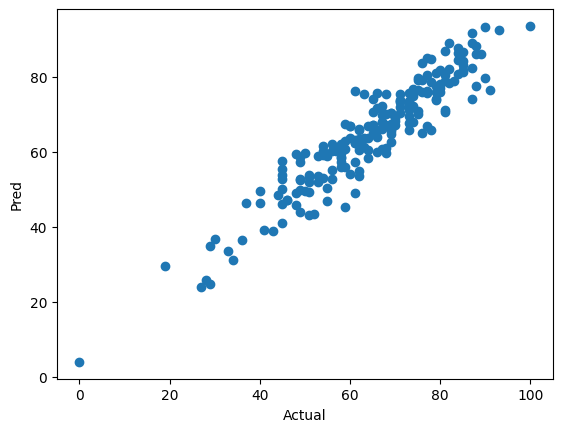

In [26]:
plt.scatter(y_test , y_pred)
plt.xlabel("Actual")
plt.ylabel("Pred")

<Axes: xlabel='math score'>

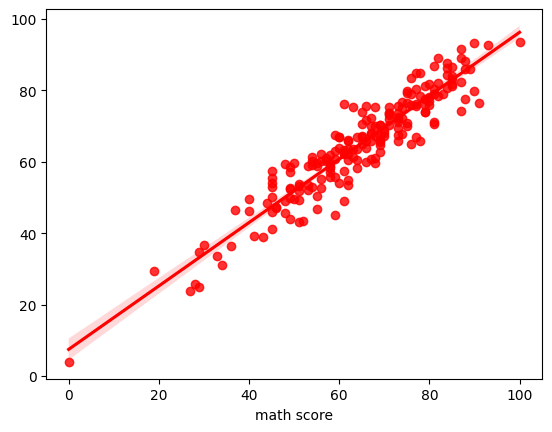

In [29]:
sns.regplot(x = y_test , y = y_pred , color="Red" , ci=False )